In [1]:
# bibliotecas
import pandas as pd             # manipulação dos dados
import numpy as np              # suporte de calculos
import matplotlib.pyplot as plt # visualização grafica
import seaborn as sns           # visualização grafica avançada
import plotly.express as px     # visualização grafica Interativa
from matplotlib.ticker import FuncFormatter # auxiliar visualização do plt/sns

In [2]:
# configurações
pd.set_option('display.float_format', lambda x: f'{x:,.2f}') # demonstra numeros no pandas em float
formatter = FuncFormatter(lambda x, _: f'{int(x):,}') # Formatter que converte o número para inteiro legível

## Carregamento dos Dados

Carregamos separado porque o dataset já vem dividido temporalmente.
Train = 2019, Test = 2020. Juntar e re-separar aleatoriamente causaria
data leakage, ou seja, informação do futuro vazando para o treino.

In [ ]:
# Carrega dados
df_train = pd.read_csv('../data/raw/fraudTrain.csv', index_col=0) # dados de 2019
df_test = pd.read_csv('../data/raw/fraudTest.csv', index_col=0)   # dados de 2020
# linhas x colunas
print(f'df_train: {df_train.shape}')
print(f'df_test: {df_test.shape}')

## Reconhecimento

Realizando reconhecimento do dados se precisam modelar ou precisam de limpeza primeiro

In [4]:
# visualização df_train
display(df_train.head())

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.08,-81.18,"3,495.00","Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,"1,325,376,018.00",36.01,-82.05,0.00
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.89,-118.21,149.00,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,"1,325,376,044.00",49.16,-118.19,0.00
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.18,-112.26,"4,154.00",Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,"1,325,376,051.00",43.15,-112.15,0.00
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.23,-112.11,"1,939.00",Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,"1,325,376,076.00",47.03,-112.56,0.00
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.42,-79.46,99.00,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,"1,325,376,186.00",38.67,-78.63,0.00


In [5]:
# confirmar compatibilidade de schema
print(df_train.dtypes.equals(df_test.dtypes))
print(f'Colunas train: {df_train.columns.tolist()}')
print(f'Colunas test:  {df_test.columns.tolist()}')

False
Colunas train: ['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']
Colunas test:  ['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


Com a visuluzação resolvi olhar a fundo aque se refere cada dimensão um das dimensões do dataset
- trans_date_trans_time = data e hora da transacao
- cc_num = numero do cartao (anonimizado) - identificador
- merchant = nome do comerciante
- category = categoria do comerciante (gas_transport, shopping, etc.)
- amt = valor da transacao em dolares
- first = primeiro nome do titular - identificador
- last = sobrenome do titular - identidicador
- gender = genero (M/F)
- street = endereco do titular
- city = cidade do titular
- state = estado do titular
- zip = CEP do titular - identificador
- lat = latitude do titular
- long = longitude do titular
- city_pop = populacao da cidade
- job = profissao do titular
- dob = data de nascimento
- trans_num = ID unico da transacao - identificador
- unix_time = timestamp unix
- merch_lat = latitude do comerciante
- merch_long = longitude do comerciante
- is_fraudint = target — 0 legítima, 1 fraude

In [6]:
# visao geral consolidada conjunto de treino
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 341225 entries, 0 to 341224
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  341225 non-null  object 
 1   cc_num                 341225 non-null  int64  
 2   merchant               341225 non-null  object 
 3   category               341225 non-null  object 
 4   amt                    341225 non-null  float64
 5   first                  341224 non-null  object 
 6   last                   341224 non-null  object 
 7   gender                 341224 non-null  object 
 8   street                 341224 non-null  object 
 9   city                   341224 non-null  object 
 10  state                  341224 non-null  object 
 11  zip                    341224 non-null  float64
 12  lat                    341224 non-null  float64
 13  long                   341224 non-null  float64
 14  city_pop               341224 non-null  f

In [7]:
# contagem de nulos no conjunto de treino
df_train.isnull().sum()

,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,1
last,1
gender,1
street,1
city,1


In [8]:
# contagem de duplicados
print(df_train.duplicated().sum())
print(df_test.duplicated().sum())

0
0


In [9]:
# Valores únicos por coluna — identifica colunas de ID e categóricas
df_train.nunique()

,0
trans_date_trans_time,336234
cc_num,936
merchant,693
category,14
amt,32172
first,341
last,472
gender,2
street,936
city,859


In [ ]:
# visualiza data, minima e maxima do df_train
trans_time = pd.to_datetime(df_train['trans_date_trans_time'])
print(f'Data minima: {trans_time.min()}')
print(f'Data maxima: {trans_time.max()}')
# visualiza data, minima e maxima do df_train
trans_time = pd.to_datetime(df_test['trans_date_trans_time'])
print(f'Data minima: {trans_time.min()}')
print(f'Data maxima: {trans_time.max()}')

## Periodo do Dataset

Train: 01/01/2019 a 10/06/2019
Test:  21/06/2020 a 31/12/2020
Gap:   julho 2019 a maio 2020 ausente nos dois arquivos

## Distribuição  
com o reconhecimento dos dados realizados visto que não temos dados nulos e nem duplicados, e visualizado o que e cada variável representa, seguirei com a análise do comportamento das variaveis individualmente.
Tem slgo estranho que pode enganar o modelo?

In [10]:
# visuliza colunas númericas relevantes
colunas_numericas = ['amt','lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'unix_time'] # zip e cc_num são identificadores, não métricas, excluí da análise
# analise das colunas numericas
df_train[colunas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
amt,"341,225.00",70.53,155.26,1.00,9.65,47.56,83.28,"17,897.24"
lat,"341,224.00",38.54,5.08,20.03,34.67,39.35,41.94,66.69
long,"341,224.00",-90.21,13.78,-165.67,-96.80,-87.46,-80.13,-67.95
city_pop,"341,224.00","89,784.39","304,053.70",23.00,743.00,"2,456.00","20,478.00","2,906,700.00"
merch_lat,"341,224.00",38.54,5.11,19.03,34.73,39.36,41.96,67.51
merch_long,"341,224.00",-90.21,13.79,-166.67,-96.89,-87.42,-80.20,-66.96
unix_time,"341,224.00","1,332,945,050.47","3,989,909.54","1,325,376,018.00","1,329,667,902.50","1,333,168,311.50","1,336,378,366.75","1,339,295,900.00"


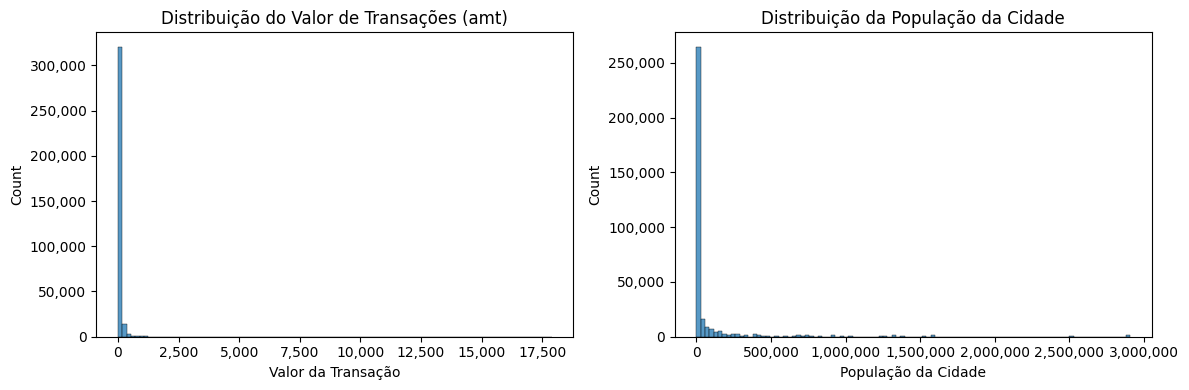

In [11]:
# visualizar amt e city_pop que possuem médias, medianas, e desvio padrão e valor máximo muitos discrepantes
fig, ax = plt.subplots(1,2, figsize=(12,4))

# visualização da distribuição do Valor de Transações (amt)
sns.histplot(df_train['amt'], bins=100, ax=ax[0])
ax[0].set_title('Distribuição do Valor de Transações (amt)')
ax[0].set_xlabel('Valor da Transação')
ax[0].xaxis.set_major_formatter(formatter)
ax[0].yaxis.set_major_formatter(formatter)

# visualização da distribuição da População da Cidade
sns.histplot(df_train['city_pop'], bins=100, ax=ax[1])
ax[1].set_title('Distribuição da População da Cidade')
ax[1].set_xlabel('População da Cidade')
ax[1].xaxis.set_major_formatter(formatter)
ax[1].yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

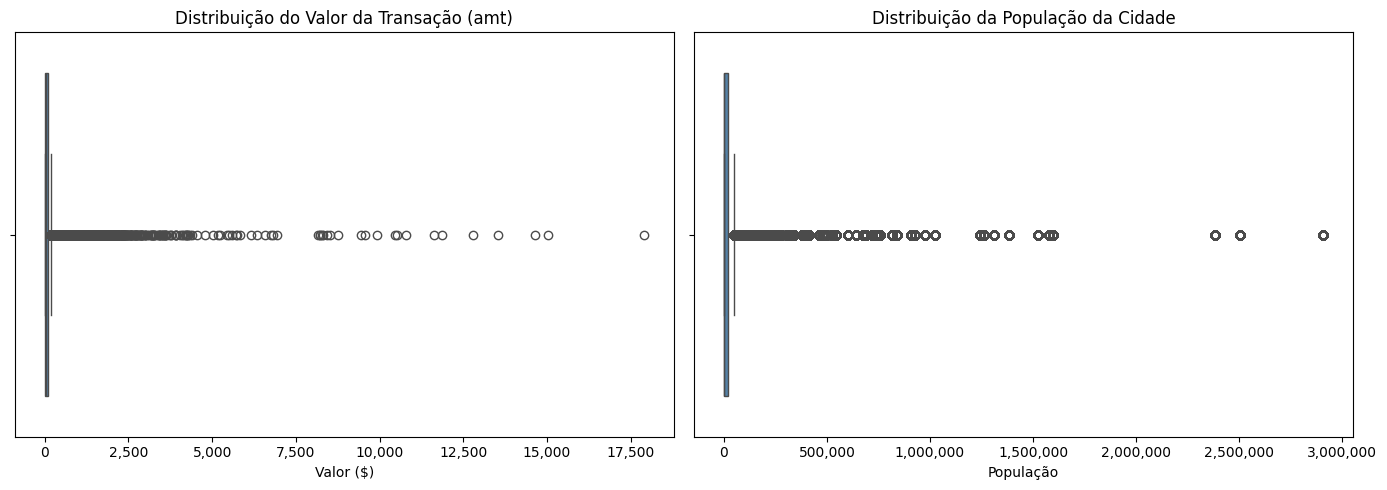

In [12]:
# Caudas muitos longas agrupadas nas partes mais baixas, o que faz parecer outliers, irei utilizar o boxplot para verificar melhor

# visualizar amt e city_pop em boxplot para melhor visualização dos outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# visualizar boxplot do amt
sns.boxplot(x=df_train['amt'], ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição do Valor da Transação (amt)')
axes[0].set_xlabel('Valor ($)')
axes[0].xaxis.set_major_formatter(formatter)

# visualizar boxplot do city_pop
sns.boxplot(x=df_train['city_pop'], ax=axes[1], color='steelblue')
axes[1].set_title('Distribuição da População da Cidade')
axes[1].set_xlabel('População')
axes[1].xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

In [14]:
#Skew e Kurt das colunas numericas para atestar assimetria
status_assimetria = pd.DataFrame({
    'skew': df_train[colunas_numericas].skew(),
    'kurt': df_train[colunas_numericas].kurt()
})

print(status_assimetria)

            skew     kurt
amt        31.36 2,147.39
lat        -0.17     0.85
long       -1.15     1.85
city_pop    5.57    37.27
merch_lat  -0.17     0.83
merch_long -1.15     1.84
unix_time  -0.17    -1.12


## Conclusão — Distribuição Numérica

é possivel perceber uma cauda muito longa nas duas variaveis analisadas, pois temos em amt a maioria das transações centralizadas abaixo de mil doláres e as transações maiores ficam quase invisiveis, e a maioria dos clientes se concentram em cidades pequenas tornando a visualização das cidade grandes praticamente impossivel, dificultando muito a visualização real dos dados.

`amt` e `city_pop` apresentam assimetria severa à direita com outliers
plausíveis (não são erros de coleta). Decisão: aplicar log1p no
preprocessing antes de modelar. Não remover outliers.

### Assimetria e Curtose

| Coluna    | Skew  | Kurt     | Decisão                        |
|-----------|-------|----------|--------------------------------|
| amt       | 31.36 | 2147.39  | log1p obrigatório              |
| city_pop  | 5.57  | 37.27    | log1p obrigatório              |
| lat       | -0.17 | 0.85     | sem transformação              |
| long      | -1.15 | 1.85     | vira feature de distância      |
| merch_lat | -0.17 | 0.83     | sem transformação              |
| merch_long| -1.15 | 1.84     | vira feature de distância      |
| unix_time | -0.17 | -1.12    | descartar após extrair hora/dia|.

In [16]:
#verificar distribuição da variavel target (is_fraud)
print(df_train['is_fraud'].value_counts())
print(df_train['is_fraud'].value_counts(normalize=True) * 100)

is_fraud
0.00    338847
1.00      2377
Name: count, dtype: int64
is_fraud
0.00   99.30
1.00    0.70
Name: proportion, dtype: float64


## Distribuição do Target

| Classe | Absoluto | Percentual |
|--------|----------|------------|
| 0 (legítima) | 1.289.169 | 99.30% |
| 1 (fraude)   | 7.506     | 0.70%  |

Desbalanceamento severo, classe minoritária abaixo de 1%.
Estratégia: SMOTE no treino + class_weight='balanced' nos modelos.
Métricas: AUC-ROC, Precision-Recall e F1 pois são imunes ao fato do modelo "chutar" apenas e ter alto desempenho, e descartar Acurácia, como metrica de avaliação.

In [19]:
# Analise descritiva das categoricas relevantes
categoricas = {
    'gender': df_train['gender'],
    'state': df_train['state'],
    'job': df_train['job'],
    'merchant': df_train['merchant'],
    'category': df_train['category']
}

for coluna, serie in categoricas.items():
    print(f'{"="*50}')
    print(f'Coluna: {coluna.upper()}')
    print(f'Valores unicos: {serie.nunique()}')
    print(serie.value_counts(normalize=True).head(10) * 100)
    print()

Coluna: GENDER
Valores unicos: 2
gender
F   54.70
M   45.30
Name: proportion, dtype: float64

Coluna: STATE
Valores unicos: 51
state
TX   7.29
NY   6.46
PA   6.13
CA   4.37
MI   3.60
OH   3.53
IL   3.33
FL   3.33
AL   3.18
MO   2.99
Name: proportion, dtype: float64

Coluna: JOB
Valores unicos: 481
job
Film/video editor            0.75
Exhibition designer          0.72
Surveyor, land/geomatics     0.68
Naval architect              0.66
Designer, ceramics/pottery   0.64
Materials engineer           0.62
Systems developer            0.61
IT trainer                   0.61
Environmental consultant     0.59
Financial adviser            0.57
Name: proportion, dtype: float64

Coluna: MERCHANT
Valores unicos: 693
merchant
fraud_Kilback LLC              0.34
fraud_Cormier LLC              0.29
fraud_Schumm PLC               0.28
fraud_Dickinson Ltd            0.27
fraud_Boyer PLC                0.26
fraud_Kuhn LLC                 0.26
fraud_Berge LLC                0.22
fraud_Bartoletti-Wunsch  

## Análise das Categóricas

| Coluna   | Únicos | Situação         | Decisão notebook 02         |
|----------|--------|------------------|-----------------------------|
| gender   | 2      | saudável, distribuição equilibrada        | encoding binário F=0, M=1   |
| state    | 51     | saudável, nenhum predominante       | One-Hot encoding            |
| category | 14     | saudável, distruição equilibrada , sem raridades        | One-Hot encoding            |
| job      | 481    | alta cardinalidade | agrupar por setor/renda   |
| merchant | 693    | alta cardinalidade + prefixo fraud_ | descartar ou remover prefixo|

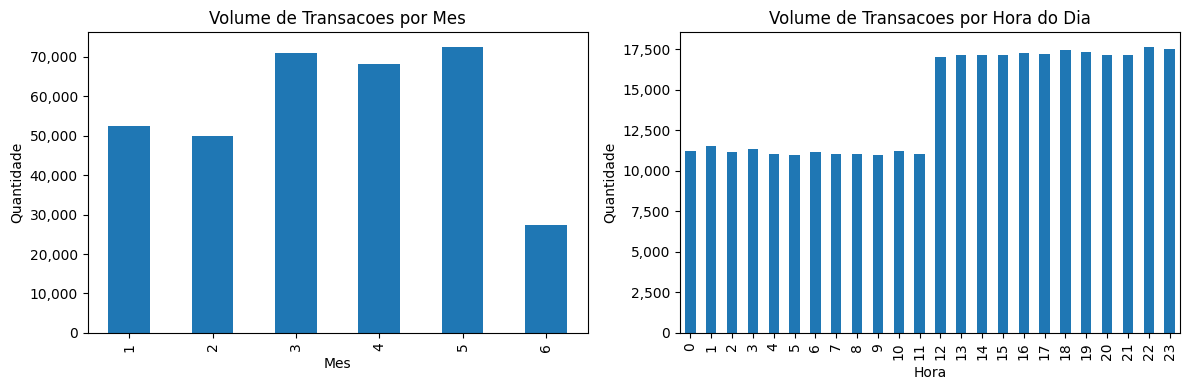

In [25]:
# Converte so para visualizacao — nao salva no df_train
trans_time = pd.to_datetime(df_train['trans_date_trans_time'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Volume por mes
trans_time.dt.month.value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Volume de Transacoes por Mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Quantidade')
axes[0].yaxis.set_major_formatter(formatter)

# Volume por hora
trans_time.dt.hour.value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title('Volume de Transacoes por Hora do Dia')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Quantidade')
axes[1].yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

## Sazonalidade

Junho parace menor indicando que teve menos transações, porém como analisado, é um dado truncado e não sazonalidade real, visto que os dados de 2019 vai somente até 10 junho de 2019

## Hipoteses Pendentes

### Camada 3 — Relacao com Target
- [ ] Taxa de fraude por category,  esperado: shopping_net e misc_net mais altas
- [ ] Taxa de fraude por gender,  hipotese: sem diferenca significativa
- [ ] Taxa de fraude por state, hipotese: estados com mais transacoes online tem taxa maior
- [ ] Distribuicao de amt entre fraude e nao fraude, esperado: fraudes tem valor mais alto
- [ ] Horas têm volume baixo mais nao nulo no periodo de 0 a 11, hipotese: esse volume de madrugada vai ter taxa de fraude maior proporcionalmente



### Camada 4 — Multivariada
- [ ] gender x category, mulheres e homens tem categorias de compra diferentes?
- [ ] category x amt, categorias de alto valor tem mais fraude?
- [ ] state x category, padroes regionais de categoria?

### Decisoes Pendentes notebook 02
- [ ] log1p em amt e city_pop
- [ ] Remover prefixo fraud_ do merchant
- [ ] Target Encoding em job e merchant
- [ ] Extrair hora, dia da semana e mes do unix_time
- [ ] Calcular distancia entre cliente e merchant via lat/long
- [ ] Remover unix_time